In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
pcor=pd.read_csv("Kidney Clear Cell Carcinoma_Kidney_Primary Tumor_partialcorr.csv",index_col=0)
wcor=pd.read_csv("coexpression/Kidney Clear Cell Carcinoma_Kidney_Primary Tumor_corr.csv",index_col=0)

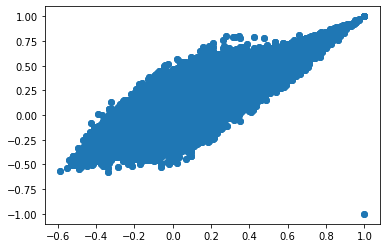

In [3]:
plt.scatter(wcor.loc[pcor.index,pcor.index],pcor)

In [4]:
from scipy.stats import spearmanr
spearmanr(wcor.loc[pcor.index,pcor.index].stack(),pcor.stack())

SpearmanrResult(correlation=0.8963789487152628, pvalue=0.0)

In [5]:
pcor.stack().sort_values().index

MultiIndex([('ENSG00000203811', 'ENSG00000203852'),
            ('ENSG00000203852', 'ENSG00000203811'),
            ('ENSG00000145147', 'ENSG00000145824'),
            ('ENSG00000145824', 'ENSG00000145147'),
            ('ENSG00000141367', 'ENSG00000242252'),
            ('ENSG00000242252', 'ENSG00000141367'),
            ('ENSG00000106400', 'ENSG00000037749'),
            ('ENSG00000037749', 'ENSG00000106400'),
            ('ENSG00000104899', 'ENSG00000141367'),
            ('ENSG00000141367', 'ENSG00000104899'),
            ...
            ('ENSG00000102901', 'ENSG00000102901'),
            ('ENSG00000174808', 'ENSG00000174808'),
            ('ENSG00000113070', 'ENSG00000113070'),
            ('ENSG00000203760', 'ENSG00000203760'),
            ('ENSG00000053747', 'ENSG00000053747'),
            ('ENSG00000125966', 'ENSG00000125966'),
            ('ENSG00000179403', 'ENSG00000179403'),
            ('ENSG00000197837', 'ENSG00000197837'),
            ('ENSG00000065320', 'ENSG00000065320

Lung Squamous Cell Carcinoma_Lung_Primary Tumor SpearmanrResult(correlation=0.9025574901596086, pvalue=0.0)
Lung Adenocarcinoma_Lung_Primary Tumor SpearmanrResult(correlation=0.8599673039526698, pvalue=0.0)
Kidney Clear Cell Carcinoma_Kidney_Primary Tumor SpearmanrResult(correlation=0.896388803472546, pvalue=0.0)
Colon Adenocarcinoma_Colon_Primary Tumor SpearmanrResult(correlation=0.9086131499356896, pvalue=0.0)
Liver Hepatocellular Carcinoma_Liver_Primary Tumor SpearmanrResult(correlation=0.9578612251238181, pvalue=0.0)


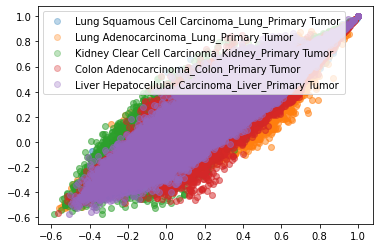

In [17]:
nml=[]
for cfile in os.listdir("coexpression/"):
    if cfile.endswith("_corr.csv") and "Tumor" in cfile:
        pcor=pd.read_csv(cfile[:-9]+"_partialcorr.csv",index_col=0)
        wcor=pd.read_csv("coexpression/"+cfile,index_col=0)
        nml.append(cfile[:-9])
        wcor=wcor.loc[pcor.index,pcor.index].stack()
        pcor=pcor.stack()
        wcor.drop([('ENSG00000203811', 'ENSG00000203852'),('ENSG00000203852', 'ENSG00000203811')],inplace=True)
        pcor.drop([('ENSG00000203811', 'ENSG00000203852'),('ENSG00000203852', 'ENSG00000203811')],inplace=True)
        plt.scatter(wcor,pcor,alpha=0.3)
        print(cfile[:-9],spearmanr(wcor,pcor))
plt.legend(labels=nml)

In [49]:
test=pd.read_csv("genexp/Kidney Clear Cell Carcinoma_Kidney_Primary Tumor_geneexp.tsv",index_col=0,sep='\t')

In [50]:
test.loc['ENSG00000203811']

TCGA-BP-4968-01    2.1158
TCGA-CJ-4890-01    2.2000
TCGA-CJ-4639-01    2.4157
TCGA-BP-5007-01    2.5283
TCGA-B0-4817-01    2.5098
                    ...  
TCGA-B0-5085-01    2.8929
TCGA-B2-4099-01    2.4338
TCGA-BP-4344-01    3.5347
TCGA-B0-4688-01    5.4367
TCGA-CJ-4875-01    2.5802
Name: ENSG00000203811, Length: 530, dtype: float64

In [51]:
test.loc['ENSG00000203852']

TCGA-BP-4968-01    2.1158
TCGA-CJ-4890-01    2.2000
TCGA-CJ-4639-01    2.4157
TCGA-BP-5007-01    2.5283
TCGA-B0-4817-01    2.5098
                    ...  
TCGA-B0-5085-01    2.8929
TCGA-B2-4099-01    2.4338
TCGA-BP-4344-01    3.5347
TCGA-B0-4688-01    5.4367
TCGA-CJ-4875-01    2.5802
Name: ENSG00000203852, Length: 530, dtype: float64